In [ ]:
!pip install legacy-cgi opendatasets --quiet
import opendatasets as od

od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [ ]:
# transform is used in all image (resize , made tensors  ) before training or inference
# label encoder is used to assign integer values to the labels
import torch
from torch import nn
from torch.optim import Adam
from sklearn.preprocessing import LabelEncoder
from torchvision.transforms import transforms
from torch.utils.data import Dataset , DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from  PIL import Image
import os
from torchsummary import summary
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
image_path=[]
labels =[]
for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for images in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{images}")
      labels.append(label)


In [ ]:
data_df = pd.DataFrame(zip(image_path,labels) , columns=["Image_Path","Label"])
data_df.head()
print (data_df["Label"].unique())


['dog' 'cat' 'wild']


In [ ]:
train = data_df.sample(frac=0.7,random_state=42)
test= data_df.drop(train.index)

val= test.sample(frac=0.5 , random_state=42)
test = test.drop(val.index)

print (train.shape)
print(test.shape)
print(val.shape)

(11291, 2)
(2419, 2)
(2420, 2)


In [ ]:
# now we have to encode the labels in numbers
label_encoder = LabelEncoder()
label_encoder.fit(data_df["Label"])

Transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
# now create dataset for that define custom class

class CustomImageDataset(Dataset):
    def __init__(self,dataframe,transform=None):
      self.dataframe = dataframe
      self.transform = transform
      self.label = torch.tensor(label_encoder.transform(dataframe["Label"]) ).to(device)
    def __len__ (self):
      return self.dataframe.shape[0]

    def __getitem__ (self,index):
      image_path = self.dataframe.iloc[index,0]
      label = self.label[index]
      image = Image.open(image_path).convert("RGB")
      if self.transform:
        image = self.transform(image)
      image = image.to(device)
      return image , label

In [ ]:
train_dataset = CustomImageDataset(dataframe = train , transform = Transform)
val_dataset = CustomImageDataset (dataframe = val , transform= Transform )
test_dataset = CustomImageDataset (dataframe = test , transform = Transform)


In [ ]:
train_dataset.__len__()
train_dataset.__getitem__(5)

(tensor([[[0.6627, 0.6627, 0.6706,  ..., 0.5216, 0.5255, 0.5255],
          [0.6627, 0.6627, 0.6667,  ..., 0.5255, 0.5294, 0.5216],
          [0.6627, 0.6588, 0.6627,  ..., 0.5216, 0.5176, 0.5255],
          ...,
          [0.8549, 0.8549, 0.8627,  ..., 0.4235, 0.3882, 0.3216],
          [0.8627, 0.8627, 0.8627,  ..., 0.4235, 0.3490, 0.2941],
          [0.8627, 0.8667, 0.8667,  ..., 0.4000, 0.3373, 0.2667]],
 
         [[0.6941, 0.6941, 0.7020,  ..., 0.5451, 0.5490, 0.5490],
          [0.6941, 0.6941, 0.6980,  ..., 0.5490, 0.5529, 0.5451],
          [0.6941, 0.6902, 0.6941,  ..., 0.5451, 0.5412, 0.5490],
          ...,
          [0.8784, 0.8784, 0.8863,  ..., 0.4353, 0.4118, 0.3490],
          [0.8863, 0.8863, 0.8863,  ..., 0.4353, 0.3686, 0.3216],
          [0.8863, 0.8902, 0.8902,  ..., 0.4078, 0.3608, 0.2980]],
 
         [[0.6039, 0.6039, 0.6118,  ..., 0.5373, 0.5412, 0.5412],
          [0.6039, 0.6039, 0.6078,  ..., 0.5412, 0.5451, 0.5373],
          [0.6039, 0.6000, 0.6039,  ...,

In [ ]:
# which encoded value belongs to which label we can check with the class
for encoded_val , label in enumerate(label_encoder.classes_):
  print(f"Encoded: {encoded_val} -> Label: {label}")

Encoded: 0 -> Label: cat
Encoded: 1 -> Label: dog
Encoded: 2 -> Label: wild


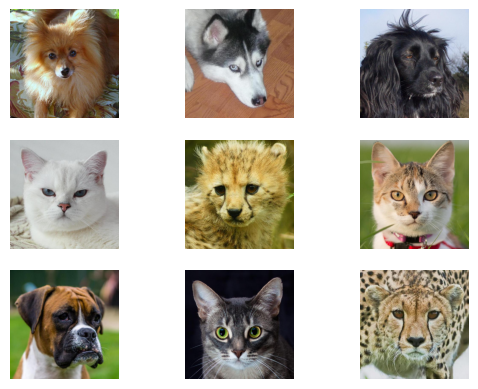

In [ ]:
#now visualization of the images
col = 3
row = 3
f , axarr = plt.subplots(row,col)

for i in range(row):
  for j in range(col):
    image = Image.open(data_df.sample(n=1) ["Image_Path"].iloc[0]).convert("RGB")
    axarr[i,j].imshow(image)
    axarr[i,j].axis('off')
plt.show()


In [ ]:
# defining constants i need afterwards
LR = 1e-4
BATCH_SIZE = 16
EPOCHS= 10

In [ ]:
train_dataloader = DataLoader(train_dataset , batch_size=BATCH_SIZE , shuffle=True)
val_dataloader = DataLoader(val_dataset , batch_size=BATCH_SIZE , shuffle=True)
test_dataloader = DataLoader(test_dataset  , batch_size= BATCH_SIZE , shuffle = True)


In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d( 3 , 32, kernel_size = 3 , padding = 1  )
    self.conv2 = nn.Conv2d  (32 , 64 , kernel_size= 3 , padding = 1)
    self.conv3= nn.Conv2d (64, 128 ,kernel_size=3  , padding = 1)
    self.pool = nn.MaxPool2d(2,2)
    self.flatten = nn.Flatten()
    self.relu = nn.ReLU()
    self.linear = nn.Linear( (128*16*16) , 128 )
    self.output = nn.Linear ( 128 , len(data_df["Label"].unique())  )

  def forward (self,x ):
    x = self.conv1(x)   # 3 , 128 , 128
    x = self.pool (x)   # 32 , 64 , 64
    x = self.relu(x)

    x = self.conv2(x)   # 32 , 64 , 64
    x = self.pool (x)   # 64 , 32 , 32
    x = self.relu(x)

    x = self.conv3(x)   # 64 , 16 , 16
    x = self.pool (x)   # 128, 16 , 16
    x = self.relu (x)

    x = self.flatten(x)

    x = self.linear(x)
    x = self.relu(x)
    x = self.output(x)
    return x

In [ ]:
model = Net().to(device)
summary (model , input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [ ]:
losscal = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters() , LR)
# now i did the model summary now we have to train the model
total_train_loss = []
total_val_loss = []
total_train_acc = []
total_val_acc = []

for epoch in range(EPOCHS):
  train_loss= 0
  train_acc=0
  val_acc = 0
  val_loss =0

  for image , label in train_dataloader:
    # it comes in batches of 16

    output = model(image)
    batch_loss = losscal(output, label)
    train_loss += batch_loss.item()

    batch_acc = (torch.argmax(output, axis =1) == label  ).sum().item()
    train_acc += batch_acc

    optimizer.zero_grad()
    batch_loss.backward()
    optimizer.step()

  with torch.no_grad():
    for image,label in val_dataloader:
      output = model(image)
      batch_loss = losscal(output,label)
      val_loss +=batch_loss.item()

      batch_acc = (torch.argmax(output, axis =1) == label  ).sum().item()
      val_acc += batch_acc

    total_train_acc.append(round (train_acc/train_dataset.__len__() , 4) )
    total_train_loss.append(round(train_loss/1000 ,4 ) )

    total_val_acc.append(round (val_acc/val_dataset.__len__() , 4) )
    total_val_loss.append(round(val_loss/1000 ,4 ))


  print ( f" Train Accuracy: {round (train_acc/train_dataset.__len__() , 4)} Train Loss : {round(train_loss/1000 ,4 )}  Validation Accuracy {round (val_acc/val_dataset.__len__() , 4)} Validation Loss {round(val_loss/1000 ,4 )} " )


 Train Accuracy: 0.9224 Train Loss : 0.153  Validation Accuracy 0.8983 Validation Loss 0.0412 
 Train Accuracy: 0.938 Train Loss : 0.1182  Validation Accuracy 0.936 Validation Loss 0.0246 
 Train Accuracy: 0.9514 Train Loss : 0.0946  Validation Accuracy 0.9496 Validation Loss 0.0215 
 Train Accuracy: 0.964 Train Loss : 0.0718  Validation Accuracy 0.9455 Validation Loss 0.0233 
 Train Accuracy: 0.9704 Train Loss : 0.0593  Validation Accuracy 0.9483 Validation Loss 0.0213 
 Train Accuracy: 0.9748 Train Loss : 0.05  Validation Accuracy 0.9574 Validation Loss 0.0199 
 Train Accuracy: 0.9804 Train Loss : 0.041  Validation Accuracy 0.9541 Validation Loss 0.0209 
 Train Accuracy: 0.9829 Train Loss : 0.0348  Validation Accuracy 0.957 Validation Loss 0.0193 
 Train Accuracy: 0.9878 Train Loss : 0.0265  Validation Accuracy 0.9595 Validation Loss 0.0196 
 Train Accuracy: 0.9896 Train Loss : 0.0224  Validation Accuracy 0.9636 Validation Loss 0.0198 


In [ ]:
# we did training and validation now testing
test_loss = 0
test_acc = 0
with torch.no_grad():
  for data in test_dataloader :
      image , label = data
      prediction = model(image)
      batch_loss = losscal(prediction,label)
      test_loss += batch_loss.item()
      batch_acc = (torch.argmax(prediction,axis =1 ) == label).sum().item()
      test_acc +=batch_acc

print (f"Test Accuracy {round(test_acc/test_dataset.__len__() , 4)} Test Loss {round(test_loss/1000 , 4)}")

Test Accuracy 0.9508 Test Loss 0.0215


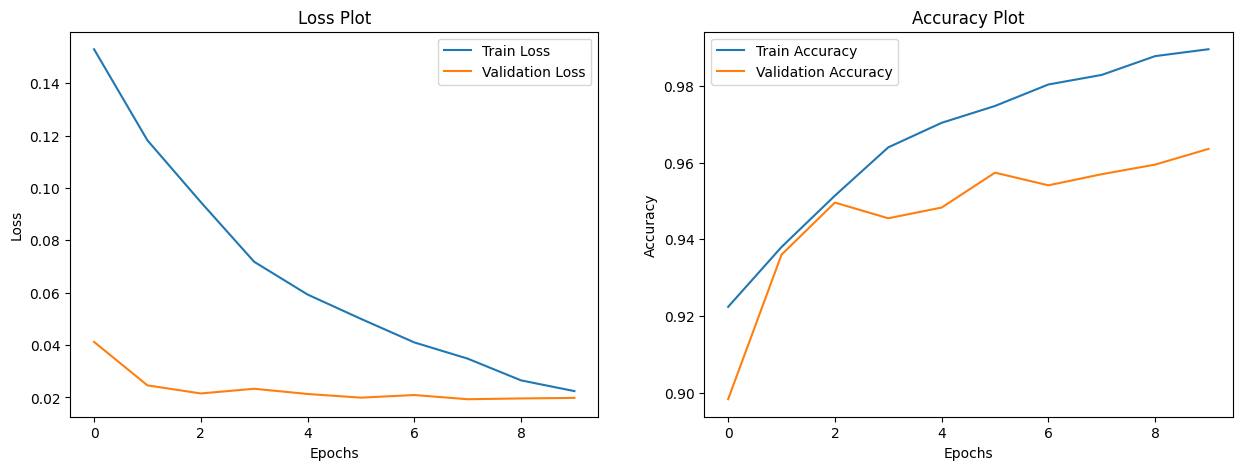

In [170]:
# now visualize our loss and accuracy for training and validation
row = 1
col = 2
f , axs = plt.subplots( row,  col , figsize=(15,5))

axs[0].plot(total_train_loss, label = "Train Loss")
axs[0].plot(total_val_loss , label = "Validation Loss")
axs[0].set_title("Loss Plot")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()


axs[1].plot(total_train_acc, label = "Train Accuracy")
axs[1].plot(total_val_acc , label = "Validation Accuracy")
axs[1].set_title("Accuracy Plot")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()

In [180]:
# what we do
# we read the image
# we transform it to our size and change its datatype as desire and made it tensor thorough Transform
# Then we will give it to model to predict
# then we inverse label encoder to see the result classificationn

def predict_image(image_path):
  image = Image.open(image_path).convert("RGB")
  image = Transform(image).unsqueeze(0).to(device)
  output = model(image)
  output = torch.argmax(output,axis =1).item()
  output = label_encoder.inverse_transform([output])
  return output

In [181]:
predict_image("/download.jpg")

array(['cat'], dtype=object)